# Notebook for constructing the results figures for the canonical model with variable k2/Q: Figures 2 and A4

## Preamble

### Load packages required

In [1]:
#SJL 6/2020
#Script to plot the change in surface length for planets in the canonical model


###########################################################
###########################################################
###########################################################
import numpy as np
import scipy as sp
import sys
import os
import struct
from scipy import constants as const

import scipy.integrate as integrate
from scipy.optimize import curve_fit

#package to use wildcards 
import fnmatch

from scipy.interpolate import LinearNDInterpolator
#from matplotlib.mlab import griddata
from scipy.interpolate import griddata

#plotting packages
import matplotlib as mpl
#mpl.use('PDF')
import matplotlib.pyplot as plt
import pylab
import matplotlib.cm as cm
from matplotlib import gridspec

cwd = os.getcwd()
print(cwd)
if sys.platform== 'darwin':
    sys.path.insert(0, cwd+'/Support_scipts')
    print(cwd+'/Support_scripts')
elif (sys.platform== 'win32') | (sys.platform== 'win64'):
    sys.path.insert(0,cwd+"\\Support_scipts")


#HERCULES_structures
from HERCULES_structures import *
from surface_size_calc import *
from HERCULES_random_planet_database_structure_1D import *

#functions for calculating non-evenly spaced numerical differentials
from gradients import *

#import colormaps
import colormaps as cmaps
import matplotlib.cm as cm

import svglib.svglib as svglib
svglib.register_font('helvetica', './Helvetica.ttc')


/Users/vq21447/Documents/Lock_2026_SI
/Users/vq21447/Documents/Lock_2026_SI/Support_scripts
CHECK THE LOCATION OF ODYSSEY BACKUP
CHECK THE LOCATION OF ODYSSEY BACKUP


('helvetica', True)

### Define constants to normalize axes etc.

In [2]:
########################################################################################
########################################################################################
########################################################################################
#CONSTANTS
MEarth=5.972E24
LEM=3.5E34
REarth=6.371E6
MMoon=7.34767309E22

aMoon=0.3844E9
aCassini=30*REarth
aRoche=2.9*REarth

#for HERCULES
MEarth_H=5.9879648E24
LEM_H=3.53E34

### Set parameters and select bodies to plot

In [3]:
########################################################################################
########################################################################################
########################################################################################
#PARAMS
Hdir='Earth_correct_params_S3.20c'
Hname='Earth_correct_params_S3.20c'

#flag as to whether to run in plotting mode or whether to redo calculations
flag_calc=0

#reference flaf (0: to a set planet, 1: to an interpolated AM value)
flag_ref=1

#calculate reference AM, here present-day L of Earth
L_present=(LEM)-(MMoon)*np.sqrt(const.G*aMoon*MEarth)
L_compare=L_present
AMref=str(L_compare/LEM)

#Multiples of crust to use in panel b
Ncrust=[1.,3.0,10]
Mfpoints=np.asarray(Ncrust)*2.77E22/MEarth

#number of contor lines
Ncont=20

## Main script
### Load in HERCULES planetary structure database

In [4]:
########################################################################################
########################################################################################
########################################################################################
#MAIN

########################################################################################
#read in the database of HERCULES planets

if flag_calc==1:
    Hdatabase=HERCULES_random_planet_database_1D()
    Hdatabase.make_array(Hdir,Hname)
    Hdatabase.initialize_interpolation([0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1],\
                                       [0,0,Mfpoints.tolist(),0,0,0,0,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0]], flag_extrap=1)
    
    #extract the latitudes for each Mu point
    Nmu=Hdatabase.parr[0].Nmu
    lat=np.arccos(Hdatabase.parr[0].layers[0].mu)*180/np.pi

   #use a cosntant a0
    a0=2.9*REarth
    Ltot=LEM
    
    #set the initial and final k2Q
    
    #increasing k2Q
    k2Qmin=1E-5
    k2Qmax=0.3/100 #0.3# 0.02
    
    #alternative for decreaing k2Q
    # k2Qmin=1.2
    # k2Qmax=1E-2
    
    #plot both a log and lin model
    Nmodel=2
    
    #consider a range of times at which the maximum k2Q is reached
    tmax=np.asarray([0,0.1,1,10])*1E6*const.year
    Ntmax=np.size(tmax)
    
    #resulting expoential constant
    sigma=np.log(k2Qmax/k2Qmin)/tmax
    sigma[0]=0.0
    
    #number of time points
    Nt=1000
    t=np.logspace(3,8,Nt)*const.year
    
    
    #run through and extract lengths and areas at each time point
    k2Q=np.zeros((Nt,Nmodel,Ntmax))
    a=np.zeros((Nt,Nmodel,Ntmax))
    L=np.zeros((Nt,Nmodel,Ntmax))
    
    dLdt=np.zeros((Nt,Nmodel,Ntmax))
    
    dl_lat=np.empty((Nt,Nmodel,Ntmax,Nmu))
    dl_lon=np.empty((Nt,Nmodel,Ntmax,Nmu))
    dA=np.empty((Nt,Nmodel,Ntmax,Nmu))
    
    ddl_lat_dL=np.zeros((Nt,Nmodel,Ntmax,Nmu))
    ddl_lon_dL=np.zeros((Nt,Nmodel,Ntmax,Nmu))
    ddA_dL=np.zeros((Nt,Nmodel,Ntmax,Nmu))
    
    ddl_lat_dt=np.zeros((Nt,Nmodel,Ntmax,Nmu))
    ddl_lon_dt=np.zeros((Nt,Nmodel,Ntmax,Nmu))
    ddA_dt=np.zeros((Nt,Nmodel,Ntmax,Nmu))
    
    
    for kk in np.arange(Nmodel):
        print(kk+1,'/',Nmodel)
        for i in np.arange(Ntmax):
            print('\t',i+1,'/',Ntmax)
            for j in np.arange(Nt):
                # print('\t \t',j+1,'/',Nt)
    
                #for exponential growth
                if kk==0:
                    if sigma[i]==0.0: #this is the constant k2Q=k2Qmax
                        k2Q[j,kk,i]=k2Qmax
                        integral=t[j]*k2Q[j,kk,i]
                    elif t[j]<tmax[i]:
                        k2Q[j,kk,i]=k2Qmin*np.exp(sigma[i]*t[j])
                        integral=k2Qmin*(np.exp(sigma[i]*t[j])-1)/sigma[i]
                    elif t[j]>=tmax[i]:
                        k2Q[j,kk,i]=k2Qmax
                        integral=k2Qmin*(np.exp(sigma[i]*tmax[i])-1)/sigma[i]+k2Qmax*(t[j]-tmax[i])
                        
                #for linear growth
                if kk==1:
                    if sigma[i]==0.0: #this is the constant k2Q=k2Qmin
                        k2Q[j,kk,i]=k2Qmin
                        integral=t[j]*k2Q[j,kk,i]
                    elif t[j]<tmax[i]:
                        k2Q[j,kk,i]=k2Qmin+(t[j]/tmax[i])*(k2Qmax-k2Qmin)
                        integral=k2Qmin*t[j]+((t[j]**2)/2/tmax[i])*(k2Qmax-k2Qmin)
                    elif t[j]>=tmax[i]:
                        k2Q[j,kk,i]=k2Qmax
                        integral=k2Qmin*tmax[i]+0.5*tmax[i]*(k2Qmax-k2Qmin)+k2Qmax*(t[j]-tmax[i])
    
                #calculate the orbit
                kappa=3.0*k2Q[j,kk,i]*MMoon/MEarth*(REarth**5)*np.sqrt(const.G*(MEarth+MMoon))
                a[j,kk,i]=((13.0/2.0)*kappa*integral/k2Q[j,kk,i]+(a0**(13.0/2.0)))**(2.0/13.0)
                L[j,kk,i]=Ltot-(MMoon)*np.sqrt(const.G*a[j,kk,i]*(MEarth+MMoon))
                dLdt[j,kk,i]=-0.5*MMoon/np.sqrt(const.G*a[j,kk,i]*(MEarth+MMoon))*const.G*(MEarth+MMoon)*kappa*(a[j,kk,i]**(-11.0/2.0))
    
                temp_data=Hdatabase.interp_database(L[j,kk,i],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],\
                                                   [0,0,[0],0,0,0,0,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0]],flag_extrap=1)
    
                temp=np.asarray(temp_data[16])
    
                dl_lat[j,kk,i,:]=temp[:,0]
                dl_lon[j,kk,i,:]=temp[:,1]
                dA[j,kk,i,:]=temp[:,2]
    
                ddl_lat_dL[j,kk,i,:]=temp[:,3]*np.pi/180.0
                ddl_lon_dL[j,kk,i,:]=temp[:,4]*np.pi/180.0
                ddA_dL[j,kk,i,:]=temp[:,5]*(np.pi/180.0)**2
    
                ddl_lat_dt[j,kk,i,:]=temp[:,3]*dLdt[j,kk,i]*np.pi/180.0
                ddl_lon_dt[j,kk,i,:]=temp[:,4]*dLdt[j,kk,i]*np.pi/180.0
                ddA_dt[j,kk,i,:]=temp[:,5]*dLdt[j,kk,i]*(np.pi/180.0)**2

    #activate if you want to overwrite the run data
    if 1==0:
        np.savez('Data/Figure2andA4_1', Nmu=Nmu, lat=lat, \
                 k2Q=k2Q, a0=a0, Ltot=Ltot, Nt=Nt, t=t, k2Qmin=k2Qmin, k2Qmax=k2Qmax, Nmodel=Nmodel, tmax=tmax, sigma=sigma, \
                 a=a, L=L, ddl_lat_dt=ddl_lat_dt)

        np.savez('Data/Figure2andA4_2', ddl_lon_dt=ddl_lon_dt)
        
        np.savez('Data/Figure2andA4_3', ddA_dt=ddA_dt)
                
                
else:

    temp=np.load("Data/Figure2andA4_1.npz")
    Nmu=temp['Nmu']
    lat=temp['lat']
    k2Q=temp['k2Q']
    a0=temp['a0']
    Ltot=temp['Ltot']
    Nt=temp['Nt']
    t=temp['t']
    k2Qmin=temp['k2Qmin']
    k2Qmax=temp['k2Qmax']
    Nmodel=temp['Nmodel']
    tmax=temp['tmax']
    sigma=temp['sigma']
    a=temp['a']
    L=temp['L'] 
    ddl_lat_dt=temp['ddl_lat_dt']

    temp=np.load("Data/Figure2andA4_2.npz")
    ddl_lon_dt=temp['ddl_lon_dt']

    temp=np.load("Data/Figure2andA4_3.npz")
    ddA_dt=temp['ddA_dt']

    Ntmax=np.size(tmax)

print('done')

done


### Construct Figure A4

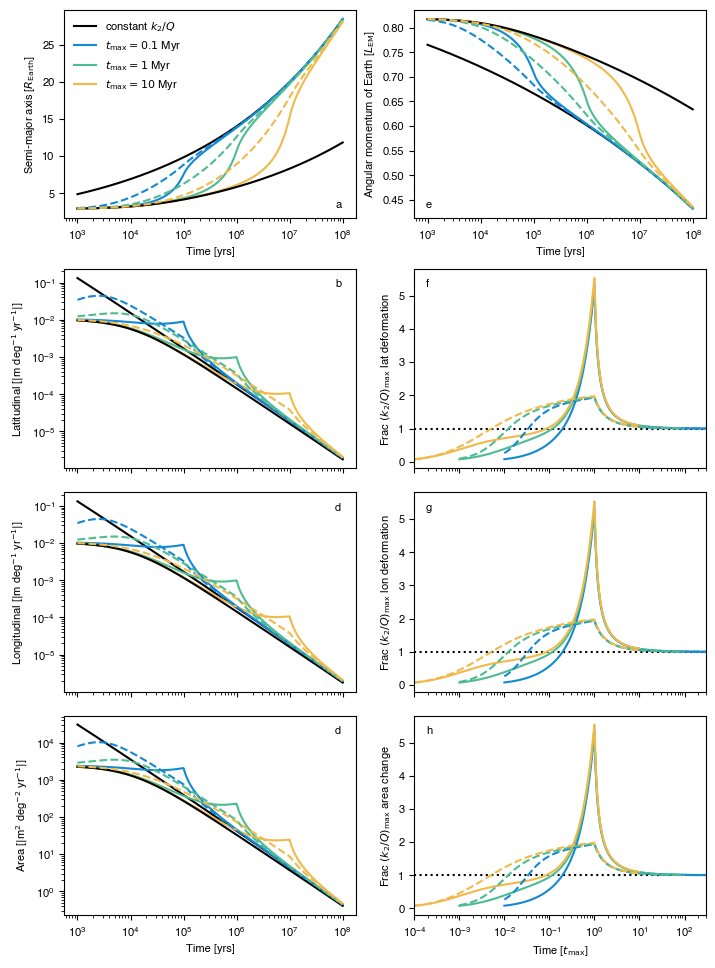

In [5]:
#Combine the previous two plots into one for final paper


#create a dummy figure figure first to avoid plotting issues
fig = plt.figure(figsize=(3.9,6.5))
font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}
mpl.rc('font', **font)
gs = gridspec.GridSpec(2, 1, height_ratios=[0.64,1])
ax=plt.subplot(gs[0])
ax1=plt.subplot(gs[1])
fig.tight_layout()
plt.savefig('Figure2.pdf')
mpl.pyplot.close(fig)

#initialise the figure
fig = plt.figure(figsize=(7.2,9.724))
gs0 = gridspec.GridSpec(2, 1,height_ratios=[1,3.1])


gs00 = gridspec.GridSpecFromSubplotSpec(1, 2, 
                                        subplot_spec=gs0[0]
                                        )


gs01 = gridspec.GridSpecFromSubplotSpec(3, 2, 
                                        subplot_spec=gs0[1]
                                        )

ax=[[],[]]
ax[0].append(plt.subplot(gs00[0]))
ax[1].append(plt.subplot(gs00[1]))

ax[0].append(plt.subplot(gs01[0]))
ax[0].append(plt.subplot(gs01[2],sharex=ax[0][1]))
ax[0].append(plt.subplot(gs01[4],sharex=ax[0][1]))

ax[1].append(plt.subplot(gs01[1]))
ax[1].append(plt.subplot(gs01[3],sharex=ax[1][1]))
ax[1].append(plt.subplot(gs01[5],sharex=ax[1][1]))

font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}

mpl.rc('font', **font)



labels=[r'constant $k_2/Q$',r'$t_\mathrm{max}=0.1$ Myr',r'$t_\mathrm{max}=1$ Myr',r'$t_\mathrm{max}=10$ Myr']

line=['-','--']
col=cmaps.parula(np.linspace(0,0.8,Ntmax))

ax[1][1].plot([1E-4,3E2],[1,1],'k:')
ax[1][2].plot([1E-4,3E2],[1,1],'k:')
ax[1][3].plot([1E-4,3E2],[1,1],'k:')

ind_mu=0
for kk in np.arange(Nmodel):
    for i in np.arange(0,Ntmax):
        
        if sigma[i]==0.0:
            #add labels to plot on first round
            if (kk==0):
                ax[0][0].plot(t/const.year,a[:,kk,i]/REarth,
                              'k-',label=labels[i])

            else:
                ax[0][0].plot(t/const.year,a[:,kk,i]/REarth,'k-')

            ax[0][1].plot(t/const.year,np.absolute(ddl_lat_dt[:,kk,i,ind_mu])*const.year,'k-')
            ax[0][2].plot(t/const.year,np.absolute(ddl_lon_dt[:,kk,i,ind_mu])*const.year,'k-')
            ax[0][3].plot(t/const.year,np.absolute(ddA_dt[:,kk,i,ind_mu])*const.year,'k-')
            
            ax[1][0].plot(t/const.year,L[:,kk,i]/LEM,'k-')
            
        else:
            #add labels to plot on first round
            if (kk==0):
                ax[0][0].plot(t/const.year,a[:,kk,i]/REarth,
                              line[kk],color=col[i],label=labels[i])

            else:
                ax[0][0].plot(t/const.year,a[:,kk,i]/REarth,line[kk],color=col[i])

            ax[0][1].plot(t/const.year,np.absolute(ddl_lat_dt[:,kk,i,ind_mu])*const.year,line[kk],color=col[i])
            ax[0][2].plot(t/const.year,np.absolute(ddl_lon_dt[:,kk,i,ind_mu])*const.year,line[kk],color=col[i])
            ax[0][3].plot(t/const.year,np.absolute(ddA_dt[:,kk,i,ind_mu])*const.year,line[kk],color=col[i])
        

            ax[1][0].plot(t/const.year,L[:,kk,i]/LEM,line[kk],color=col[i])

            if k2Qmin>k2Qmax:
                ax[1][1].plot(t/tmax[i],1.0/((np.absolute(ddl_lat_dt[:,kk,i,ind_mu]))/np.absolute(ddl_lat_dt[:,0,0,ind_mu])),line[kk],color=col[i])
                ax[1][2].plot(t/tmax[i],1.0/((np.absolute(ddl_lon_dt[:,kk,i,ind_mu]))/np.absolute(ddl_lon_dt[:,0,0,ind_mu])),line[kk],color=col[i])
                ax[1][3].plot(t/tmax[i],1.0/((np.absolute(ddA_dt[:,kk,i,ind_mu]))/np.absolute(ddA_dt[:,0,0,ind_mu])),line[kk],color=col[i])
            else:
                ax[1][1].plot(t/tmax[i],(np.absolute(ddl_lat_dt[:,kk,i,ind_mu]))/np.absolute(ddl_lat_dt[:,0,0,ind_mu]),line[kk],color=col[i])
                ax[1][2].plot(t/tmax[i],(np.absolute(ddl_lon_dt[:,kk,i,ind_mu]))/np.absolute(ddl_lon_dt[:,0,0,ind_mu]),line[kk],color=col[i])
                ax[1][3].plot(t/tmax[i],(np.absolute(ddA_dt[:,kk,i,ind_mu]))/np.absolute(ddA_dt[:,0,0,ind_mu]),line[kk],color=col[i])
            
  
ax[0][0].legend(frameon=False)

ax[1][1].set_xlim([1E-4,3E2])
    
for i in np.arange(4):
    if (i!=0):
        ax[0][i].set_yscale('log')
    ax[0][i].set_xscale('log')
    ax[1][i].set_xscale('log')

    if (i!=3)&(i!=0):
        plt.setp( ax[0][i].get_xticklabels(), visible=False)
        plt.setp( ax[1][i].get_xticklabels(), visible=False)
 
ax[0][0].set_ylabel(r'Semi-major axis [$R_\mathrm{Earth}$]')
ax[1][0].set_ylabel(r'Angular momentum of Earth [$L_\mathrm{EM}$]')

ax[0][1].set_ylabel(r'Latitudinal [$|$m deg$^{-1}$ yr$^{-1}$$|$]')
ax[0][2].set_ylabel(r'Longitudinal [$|$m deg$^{-1}$ yr$^{-1}$$|$]')
ax[0][3].set_ylabel(r'Area [$|$m$^2$ deg$^{-2}$ yr$^{-1}$$|$]')

if k2Qmin>k2Qmax:
    ax[1][1].set_ylabel(r'Inv frac $k_2/Q_\mathrm{min}$ lat deformation')
    ax[1][2].set_ylabel(r'Inv frac $k_2/Q_\mathrm{min}$ lon deformation')
    ax[1][3].set_ylabel(r'Inv frac $k_2/Q_\mathrm{min}$ area change')
else:
    ax[1][1].set_ylabel(r'Frac $(k_2/Q)_\mathrm{max}$ lat deformation')
    ax[1][2].set_ylabel(r'Frac $(k_2/Q)_\mathrm{max}$ lon deformation')
    ax[1][3].set_ylabel(r'Frac $(k_2/Q)_\mathrm{max}$ area change')

ax[0][0].set_xlabel(r'Time [yrs]')
ax[1][0].set_xlabel(r'Time [yrs]')
ax[0][3].set_xlabel(r'Time [yrs]')
ax[1][3].set_xlabel(r'Time [$t_\mathrm{max}$]')

#label axis
ax[0][0].text(0.95, 0.04, 'a', horizontalalignment='right',verticalalignment='bottom', fontsize=8,transform=ax[0][0].transAxes, color='k')
ax[0][1].text(0.95, 0.95, 'b', horizontalalignment='right',verticalalignment='top', fontsize=8,transform=ax[0][1].transAxes, color='k')
ax[0][2].text(0.95, 0.95, 'd', horizontalalignment='right',verticalalignment='top', fontsize=8,transform=ax[0][2].transAxes, color='k')
ax[0][3].text(0.95, 0.95, 'd', horizontalalignment='right',verticalalignment='top', fontsize=8,transform=ax[0][3].transAxes, color='k')

ax[1][0].text(0.04, 0.04, 'e', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[1][0].transAxes, color='k')
ax[1][1].text(0.04, 0.95, 'f', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[1][1].transAxes, color='k')
ax[1][2].text(0.04, 0.95, 'g', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[1][2].transAxes, color='k')
ax[1][3].text(0.04, 0.95, 'h', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[1][3].transAxes, color='k')


#ax[0][1].set_ylim([1,1.1])

fig.tight_layout()
plt.savefig('FigureA4.pdf')
        

### Construct figure 2

done


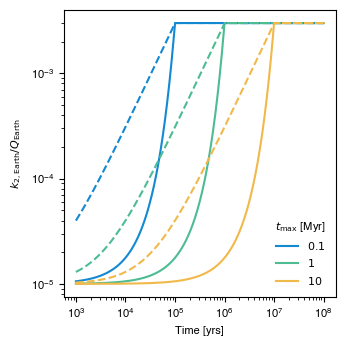

In [6]:
#plot the time evolution of k2/Q

#initialise the figure
fig = plt.figure(figsize=(3.5,3.5))
gs = gridspec.GridSpec(1, 1)
ax=[[]]
ax[0].append(plt.subplot(gs[0]))


labels=['', r'$0.1$',r'$1$',r'$10$']

line=['-','--']
col=cmaps.parula(np.linspace(0,0.8,Ntmax))

for kk in np.arange(Nmodel):
    for i in np.arange(1,Ntmax):
        
        if sigma[i]==0.0:
            #add labels to plot on first round
            if (kk==0):
                ax[0][0].plot(t/const.year,k2Q[:,kk,i],
                              'k-',label=labels[i])

            else:
                ax[0][0].plot(t/const.year,k2Q[:,kk,i],'k-')
            
        else:
            #add labels to plot on first round
            if (kk==0):
                ax[0][0].plot(t/const.year,k2Q[:,kk,i],
                              line[kk],color=col[i],label=labels[i])

            else:
                ax[0][0].plot(t/const.year,k2Q[:,kk,i],line[kk],color=col[i])


ax[0][0].legend(frameon=False, title=r'$t_{\rm max}$ [Myr]', loc='lower right')

ax[0][0].set_xscale('log')
ax[0][0].set_yscale('log')

ax[0][0].set_xlabel('Time [yrs]')
ax[0][0].set_ylabel(r'$k_{2,{\rm Earth}}/Q_{\rm Earth}$')


fig.tight_layout()

plt.savefig('Figure2.pdf')

print('done')